In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [46]:
df = pd.read_csv('Bangalore_Housing_Price.csv')

In [47]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [48]:
df.shape
df.dtypes

area_type           str
availability        str
location            str
size                str
society             str
total_sqft          str
bath            float64
balcony         float64
price           float64
dtype: object

In [49]:
print(df.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


Knowing Categorical Columns and Numerical Columns

In [50]:
numeric_colmns = df.select_dtypes(include=['int64','float64']).columns
categorical_colmns= df.select_dtypes(include=['object']).columns

print("Numeric Columns:",numeric_colmns)
print("categorical_colmns:",categorical_colmns)

Numeric Columns: Index(['bath', 'balcony', 'price'], dtype='str')
categorical_colmns: Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft'],
      dtype='str')


C:\Users\tusha\AppData\Local\Temp\ipykernel_3144\1923352393.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_colmns= df.select_dtypes(include=['object']).columns


2.Data Cleaning 

In [51]:
df.fillna({'location': 'Unkonown'}, inplace=True)

df.fillna({'bath': df['bath'].median()}, inplace=True)
df.fillna({'balcony': df['balcony'].median()}, inplace=True)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,2.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [52]:
print(df.isnull().sum())

area_type          0
availability       0
location           0
size              16
society         5502
total_sqft         0
bath               0
balcony            0
price              0
dtype: int64


handling size column

In [53]:
df['bhk'] = df['size'].str.extract('(\\d+)')
df['bhk'] = df['bhk'].astype(float)

In [54]:
print(df)

                  area_type   availability                  location  \
0      Super built-up  Area         19-Dec  Electronic City Phase II   
1                Plot  Area  Ready To Move          Chikka Tirupathi   
2            Built-up  Area  Ready To Move               Uttarahalli   
3      Super built-up  Area  Ready To Move        Lingadheeranahalli   
4      Super built-up  Area  Ready To Move                  Kothanur   
...                     ...            ...                       ...   
13315        Built-up  Area  Ready To Move                Whitefield   
13316  Super built-up  Area  Ready To Move             Richards Town   
13317        Built-up  Area  Ready To Move     Raja Rajeshwari Nagar   
13318  Super built-up  Area         18-Jun           Padmanabhanagar   
13319  Super built-up  Area  Ready To Move              Doddathoguru   

            size  society total_sqft  bath  balcony   price  bhk  
0          2 BHK  Coomee        1056   2.0      1.0   39.07  2.0  
1

In [55]:
print(df.isnull().sum())

area_type          0
availability       0
location           0
size              16
society         5502
total_sqft         0
bath               0
balcony            0
price              0
bhk               16
dtype: int64


droping Size Columns, Beacause we have bhk column

In [56]:
df.drop('size', axis=1, inplace=True)

In [57]:
#Changed the location or position of bhk column
cols = list(df.columns)
cols.remove('bhk')
cols.insert(cols.index('total_sqft'), 'bhk')

df = df[cols]

In [58]:
df = df.drop('society',axis=1) #high missing value
print(df)

                  area_type   availability                  location  bhk  \
0      Super built-up  Area         19-Dec  Electronic City Phase II  2.0   
1                Plot  Area  Ready To Move          Chikka Tirupathi  4.0   
2            Built-up  Area  Ready To Move               Uttarahalli  3.0   
3      Super built-up  Area  Ready To Move        Lingadheeranahalli  3.0   
4      Super built-up  Area  Ready To Move                  Kothanur  2.0   
...                     ...            ...                       ...  ...   
13315        Built-up  Area  Ready To Move                Whitefield  5.0   
13316  Super built-up  Area  Ready To Move             Richards Town  4.0   
13317        Built-up  Area  Ready To Move     Raja Rajeshwari Nagar  2.0   
13318  Super built-up  Area         18-Jun           Padmanabhanagar  4.0   
13319  Super built-up  Area  Ready To Move              Doddathoguru  1.0   

      total_sqft  bath  balcony   price  
0           1056   2.0      1.0  

In [59]:
df = df.dropna()
print(df.isnull().sum())

area_type       0
availability    0
location        0
bhk             0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64


#fixing total_sqft Column because it contains both value like 2100-2850 and 34.46Sq. meter

In [60]:
def convert_sqft(x):
    try:
        if '-' in str(x):
            a,b = x.split('-')
            return (float(a)+float(b))/2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

In [61]:
print(df.dtypes)

area_type           str
availability        str
location            str
bhk             float64
total_sqft      float64
bath            float64
balcony         float64
price           float64
dtype: object


In [62]:
#checking Skewness of Features
df['total_sqft'] = np.log1p(df['total_sqft'])
print(df.skew(numeric_only=True))

#Removing Redundant columns
df = df.drop(['availability'], axis=1)


bhk           4.822009
total_sqft    0.221910
bath          4.235587
balcony      -0.057135
price         8.069783
dtype: float64


3. Exploratory Data Analysis(EDA)

In [63]:
df = df.rename(columns={
    'Total_Area':'total_area',
    'BathRooms':'bathrooms'

})
print(df)

                  area_type                  location  bhk  total_sqft  bath  \
0      Super built-up  Area  Electronic City Phase II  2.0    6.963190   2.0   
1                Plot  Area          Chikka Tirupathi  4.0    7.863651   5.0   
2            Built-up  Area               Uttarahalli  3.0    7.273093   2.0   
3      Super built-up  Area        Lingadheeranahalli  3.0    7.327781   3.0   
4      Super built-up  Area                  Kothanur  2.0    7.090910   2.0   
...                     ...                       ...  ...         ...   ...   
13315        Built-up  Area                Whitefield  5.0    8.147288   4.0   
13316  Super built-up  Area             Richards Town  4.0    8.188967   5.0   
13317        Built-up  Area     Raja Rajeshwari Nagar  2.0    7.040536   2.0   
13318  Super built-up  Area           Padmanabhanagar  4.0    8.453188   4.0   
13319  Super built-up  Area              Doddathoguru  1.0    6.311735   1.0   

       balcony   price  
0          1.0

3.EDA

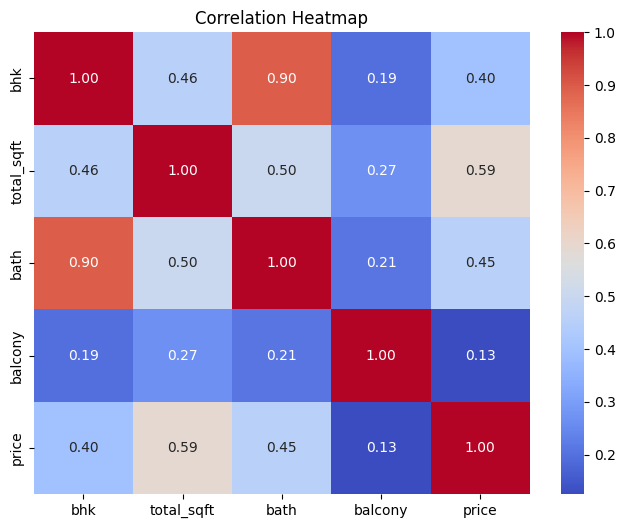

In [64]:
cols = ['bhk','total_sqft','bath','balcony','price']

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

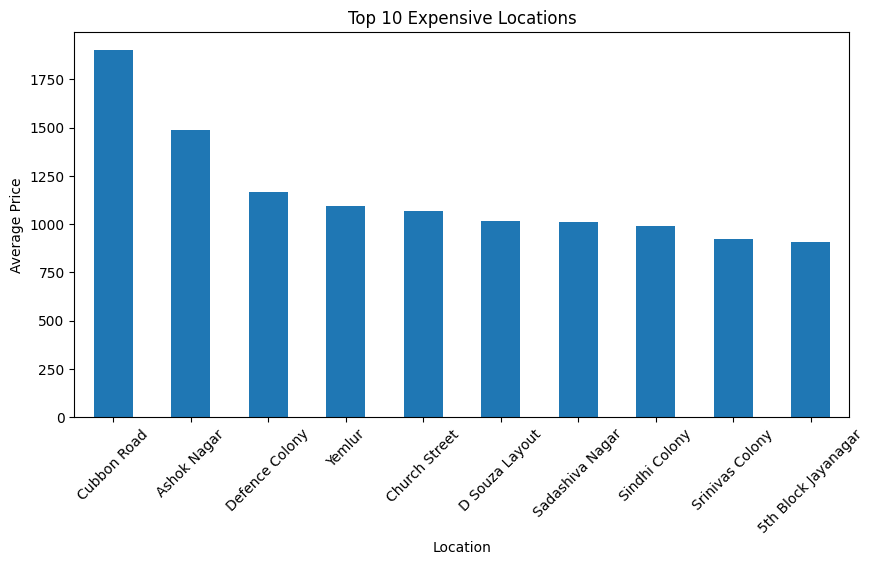

In [65]:
top_loc_price = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_loc_price.plot(kind='bar')
plt.title("Top 10 Expensive Locations")
plt.ylabel("Average Price")
plt.xlabel("Location")
plt.xticks(rotation=45)
plt.show()

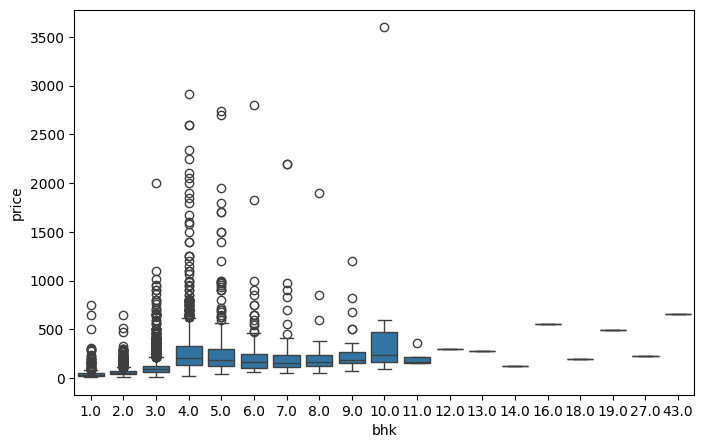

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bhk', y='price', data=df)
plt.show()

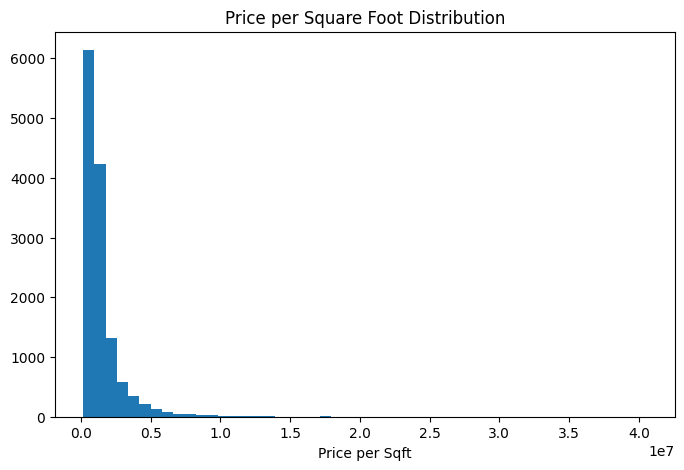

In [67]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']
plt.figure(figsize=(8,5))
plt.hist(df['price_per_sqft'], bins=50)
plt.title("Price per Square Foot Distribution")
plt.xlabel("Price per Sqft")
plt.show()

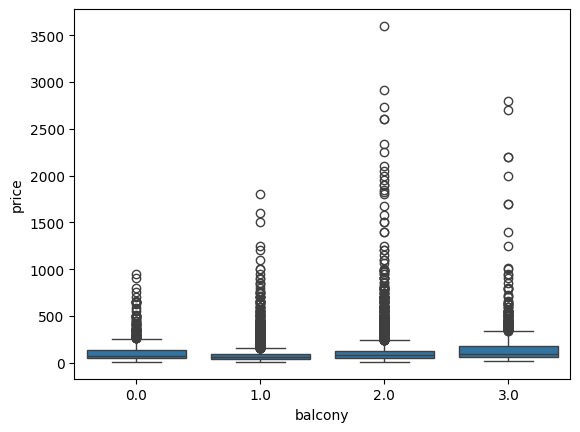

In [68]:
sns.boxplot(x='balcony', y='price', data=df)
plt.show()

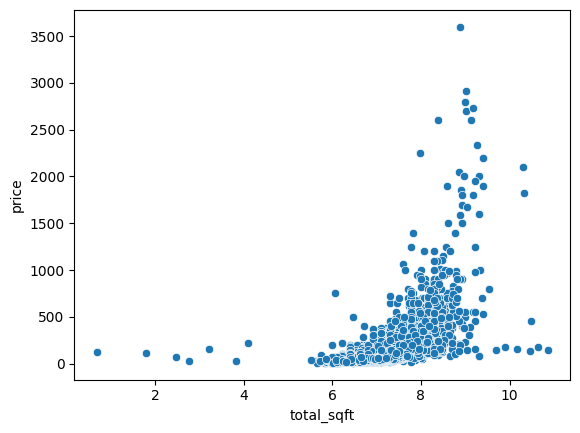

In [69]:
sns.scatterplot(x='total_sqft', y='price', data=df)
plt.show()

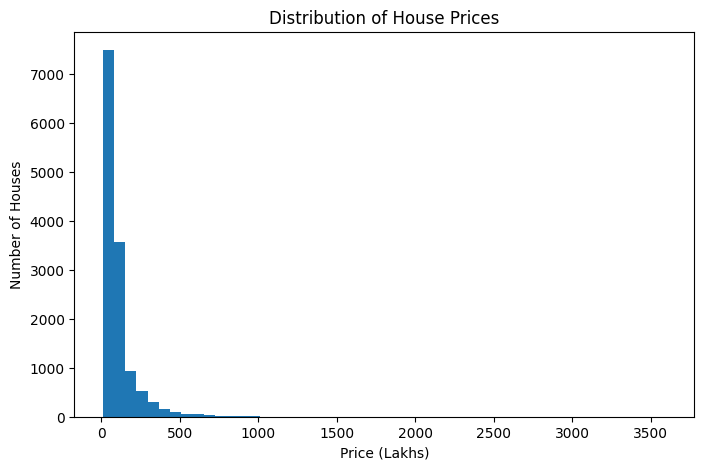

In [70]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Houses")
plt.show()

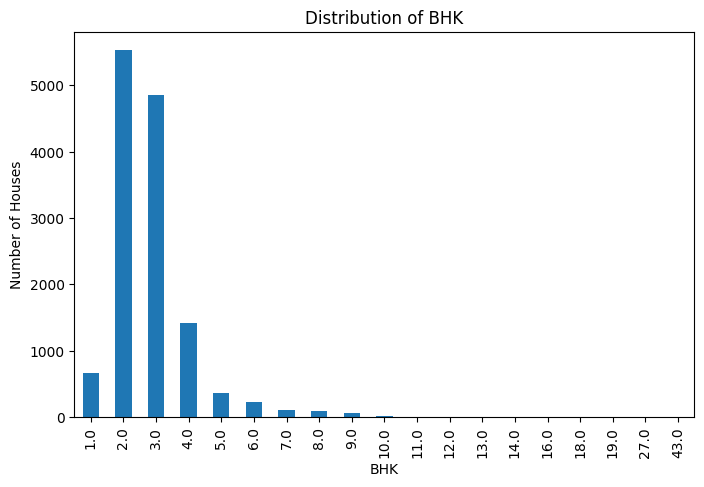

In [71]:
plt.figure(figsize=(8,5))
df['bhk'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Houses")
plt.show()

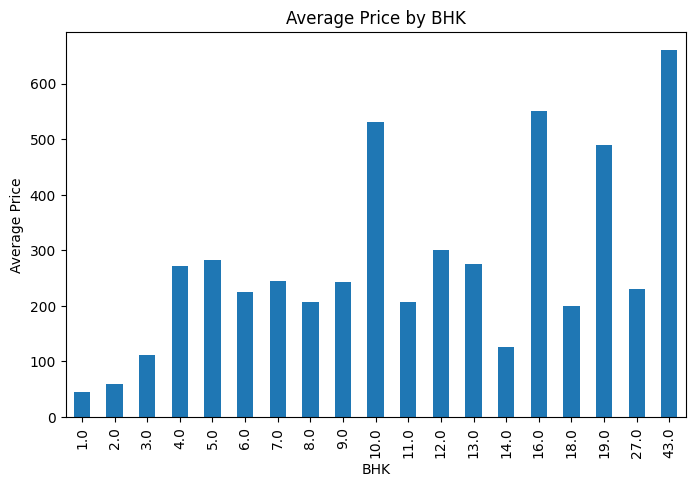

In [72]:
avg_price_bhk = df.groupby('bhk')['price'].mean()

plt.figure(figsize=(8,5))
avg_price_bhk.plot(kind='bar')
plt.title("Average Price by BHK")
plt.xlabel("BHK")
plt.ylabel("Average Price")
plt.show()

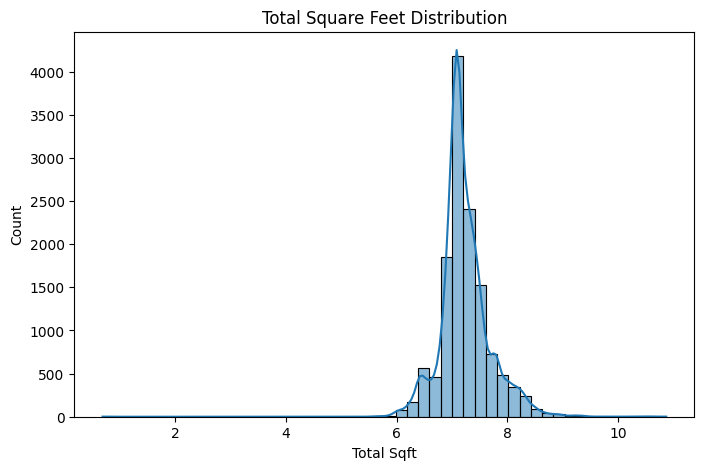

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_sqft'], bins=50, kde=True)
plt.title("Total Square Feet Distribution")
plt.xlabel("Total Sqft")
plt.ylabel("Count")
plt.show()

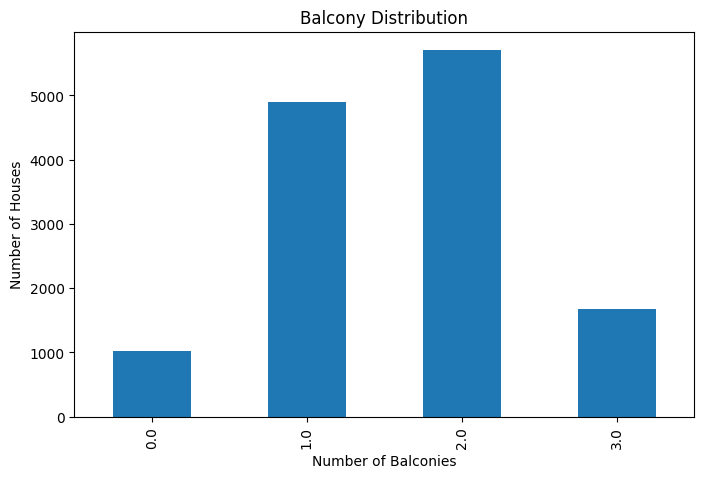

In [74]:
plt.figure(figsize=(8,5))
df['balcony'].value_counts().sort_index().plot(kind='bar')
plt.title("Balcony Distribution")
plt.xlabel("Number of Balconies")
plt.ylabel("Number of Houses")
plt.show()

4.feature Engineering

In [75]:
df.fillna({'total_sqft': df['total_sqft'].median()}, inplace=True)
print(df.isnull().sum())
#Creating Price Per sqft
df['price_per_sqft'] = (df['price']*100000) / df['total_sqft']
print(df)

area_type          0
location           0
bhk                0
total_sqft         0
bath               0
balcony            0
price              0
price_per_sqft    46
dtype: int64
                  area_type                  location  bhk  total_sqft  bath  \
0      Super built-up  Area  Electronic City Phase II  2.0    6.963190   2.0   
1                Plot  Area          Chikka Tirupathi  4.0    7.863651   5.0   
2            Built-up  Area               Uttarahalli  3.0    7.273093   2.0   
3      Super built-up  Area        Lingadheeranahalli  3.0    7.327781   3.0   
4      Super built-up  Area                  Kothanur  2.0    7.090910   2.0   
...                     ...                       ...  ...         ...   ...   
13315        Built-up  Area                Whitefield  5.0    8.147288   4.0   
13316  Super built-up  Area             Richards Town  4.0    8.188967   5.0   
13317        Built-up  Area     Raja Rajeshwari Nagar  2.0    7.040536   2.0   
13318  Super built-

In [76]:
#Removing Outliers
df = df[df['bath'] <= df['bhk'] + 2]

In [77]:
#Handling Rare Locations
location_counts = df['location'].value_counts()

rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].replace(rare_locations, 'other')

In [78]:
df = pd.get_dummies(df, columns=['location','area_type'], drop_first=True)

In [79]:
df.fillna({'total_sqft': df['total_sqft'].median()}, inplace=True)
print(df.isnull().sum())

bhk                               0
total_sqft                        0
bath                              0
balcony                           0
price                             0
                                 ..
location_Yeshwanthpur             0
location_other                    0
area_type_Carpet  Area            0
area_type_Plot  Area              0
area_type_Super built-up  Area    0
Length: 250, dtype: int64


#Model Building


In [80]:
X = df.drop('price', axis=1)
y = df['price']



In [81]:
#Train Test Splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


1.Linear regression

In [82]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

2.Decision Tree

In [83]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

3.Random Forest

In [84]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [85]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

RMSE: 27.854698819142904
MAE: 5.757566840003311
R2: 0.9600825733992767


In [86]:
print("Decision Tree Performance")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("R2:", r2_score(y_test, pred_dt))

Decision Tree Performance
RMSE: 23.94432804826321
MAE: 1.5388205417607224
R2: 0.970503471285233


In [87]:
print("Random Forest Performance")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

Random Forest Performance
RMSE: 27.05159049171194
MAE: 1.3053877539503387
R2: 0.9623511937555292
